<font face="Times New Roman" size=5>
<div dir=rtl align="center">
<font face="Times New Roman" size=5>
In The Name of God
</font>
<br>
<img src="https://logoyar.com/content/wp-content/uploads/2021/04/sharif-university-logo.png" alt="University Logo" width="150" height="150">
<br>
<font face="Times New Roman" size=4 align=center>
Sharif University of Technology - Department of Electrical Engineering
</font>
<br>
<font color="#008080" size=6>
Deep Generative Models
</font>
<hr/>
<font color="#800080" size=5>
Assignment 2 : Deep Autoregressive Models
<br>
</font>
<font size=5>
Instructor: Dr. S. Amini
<br>
</font>
<font size=4>
Fall 2025
<br>
</font>
<font face="Times New Roman" size=4>
</font>
<hr>
<font color='red'  size=4>
<br>
</font>
<font face="Times New Roman" size=4 align=center>
Feel free to ask your questions in Telegram : @ZahraSorkhei, @Ali99os
</font>
<br>
<hr>
</div></font>

**You should only change the blank sections, marked with TODO**

Pay attention to docstrings, as they may drastically help with your implementation.

You are advised to read all related papers and material, to help you better understand the design of each model.

# Question 1: Probabilistic Graph Forecasting with Autoregressive Decoders

This note gives a concise introduction to a temporal latent-variable model for **graph sequences** $\{G_t\}_{t=1}^T$ with $G_t=(X_t,A_t)$. It states the model, the training objective (ELBO) in a time-factorized form, the concrete likelihoods used for node features and edges, the effect of a deterministic decoder, and how to generate future graphs.



## Problem setup

We observe a sequence of graph snapshots

$$
G_t = (X_t, A_t), \quad t=1,\dots,T,
$$

where $X_t \in \mathbb{R}^{n \times d}$ stacks node feature vectors $x_t^v$ and $A_t \in \{0,1\}^{n \times n}$ is an undirected adjacency matrix (no self-loops). To capture temporal structure we introduce a latent trajectory

$$
Z_{1:T} = (Z_1, \dots, Z_T), \quad Z_t \in \mathbb{R}^m,
$$

where $Z_t$ is a global latent representation of the whole graph at time $t$.


## Generative (autoregressive latent) model

An autoregressive factorization is used:

$$
p_\theta(X_{1:T}, A_{1:T}, Z_{1:T})
= p(Z_1) \prod_{t=1}^{T-1} p_\theta(Z_{t+1}\mid Z_t)\; p_\theta(X_{t+1}, A_{t+1}\mid Z_t)
$$

Intuition: the latent $Z_t$ summarizes the state at $t$; a transition model $p_\theta(Z_{t+1}\mid Z_t)$ evolves it; conditioned on the current latent we predict the *next* snapshot $(X_{t+1}, A_{t+1})$.

We approximate the true posterior with an amortized encoder (e.g. a GNN+RNN):

$$
q_\phi(Z_t \mid X_{1:t}, A_{1:t}) \quad \text{(often factorized across $t$ for amortization).}
$$


## Variational lower bound (ELBO) — time decomposition

Using the variational approximation

$$
q_\phi(Z_{1:T}\mid X_{1:T},A_{1:T}) = \prod_{t=1}^T q_\phi(Z_t \mid X_{1:t},A_{1:t}),
$$

the marginal log-likelihood admits the ELBO:

$$
\log p_\theta(X_{1:T}, A_{1:T}) \ge
\mathbb{E}_{q_\phi} \Big[ \sum_{t=1}^{T-1} \log p_\theta(X_{t+1}, A_{t+1} \mid Z_t) \Big]
- \mathrm{KL}\big(q_\phi(Z_1 \mid X_1, A_1) \,\|\, p(Z_1)\big)
- \sum_{t=1}^{T-1} \mathbb{E}_{q_\phi} \Big[ \mathrm{KL}\big(q_\phi(Z_{t+1}\mid X_{1:t+1}, A_{1:t+1}) \,\|\, p_\theta(Z_{t+1}\mid Z_t)\big) \Big].
$$

Thus the objective is a sum over time: per-step reconstruction terms plus per-step KL penalties that align the encoder's posterior with the learned transition prior.



## Explicit reconstruction likelihoods

If the decoder factorizes into Gaussian node-features and Bernoulli edges:

- **Node features (per node $v$)**

$$
p_\theta(x_{t+1}^v \mid Z_t) = \mathcal{N}(x_{t+1}^v \mid \mu_\theta^v(Z_t), \Sigma_\theta^v(Z_t)),
$$

hence the feature log-likelihood (for all nodes) is

$$
\log p_\theta(X_{t+1} \mid Z_t)
= -\frac{1}{2} \sum_{v=1}^n \Big[ (x_{t+1}^v - \mu_\theta^v)^\top (\Sigma_\theta^v)^{-1} (x_{t+1}^v - \mu_\theta^v) + \log \det(2 \pi \Sigma_\theta^v) \Big].
$$

(In practice $\Sigma^v$ is taken diagonal or shared for numerical stability.)

- **Edges (for unordered pairs $u<v$)**

$$
p_\theta(A_{t+1} \mid Z_t) = \prod_{u<v} \mathrm{Bernoulli}\big(A_{t+1}^{uv} \mid \pi_\theta^{uv}(Z_t)\big),
$$

so

$$
\log p_\theta(A_{t+1} \mid Z_t) = \sum_{u<v} \Big[ A_{uv} \log \pi_{uv} + (1-A_{uv}) \log (1-\pi_{uv}) \Big].
$$

Combine them:

$$
\log p_\theta(X_{t+1}, A_{t+1} \mid Z_t) = \log p_\theta(X_{t+1} \mid Z_t) + \log p_\theta(A_{t+1} \mid Z_t).
$$


## Deterministic decoder

If the decoder is deterministic (e.g. $X_{t+1}=f_\theta(Z_t)$, $A_{t+1}=g_\theta(Z_t)$ or equivalently Gaussian with vanishing variance), then:

- The likelihood becomes a Dirac (or degenerate Gaussian); log-likelihood is $-\infty$ off the model manifold — numerically unstable.
- Deterministic decoders cannot model multimodality: a single $Z_t$ maps to a single snapshot, so they fail when the conditional distribution is multi-valued.
- Training tends to overfit (model memorizes) or produce poor uncertainty calibration. Probabilistic decoders (non-zero variance, Bernoulli edges) are preferred for stable likelihood-based training and to capture uncertainty/diversity.


## Generating future graphs

Given observed history $X_{1:T}, A_{1:T}$:

1. Infer the posterior at final time: $q_\phi(Z_T \mid X_{1:T}, A_{1:T})$ and sample $z_T \sim q_\phi$ (or use the posterior mean).
2. For $h=1$ to $H$:
   - Sample latent: $z_{T+h} \sim p_\theta(Z_{T+h} \mid z_{T+h-1})$.
   - Sample (or take mean of) snapshot: $(\tilde X_{T+h}, \tilde A_{T+h}) \sim p_\theta(\cdot \mid z_{T+h-1})$ (or use the decoder mean).





In [24]:
import math, random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import networkx as nx
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader

## 1) Synthetic dynamic graph dataset
**Goal:**  
Create dynamic graphs using SBM with Gaussian node features.

**Hints:**  
- `generate_sbm`: adjacency with `p_in` (intra) and `p_out` (inter) edges.  
- `generate_features`: node features from `N(μ_k, Σ_k)` per community.  
- `generate_sequence`: simulate T timesteps with drift and edge flips.  
- `_getitem_` / `_len_`: return sequences.  
- `collate_fn`: batch multiple sequences.

**Output:**  
- `X_seq`: `[T, n_nodes, feat_dim]`  
- `A_seq`: `[T, n_nodes, n_nodes]`

In [25]:
## TO DO

class SyntheticGraphDataset(Dataset):
    """
    Generate synthetic evolving graphs.
    - Each sequence has T snapshots.
    - Node features: random walk.
    - Edges: flip with small probability.
    """
    def __init__(self, n_nodes=30, feat_dim=4, T=40, n_seq=200, p_flip=0.03):
        self.n_nodes = n_nodes
        self.feat_dim = feat_dim
        self.T = T
        self.n_seq = n_seq
        self.p_flip = p_flip

        self.sequences = [self.generate_sequence() for _ in range(n_seq)]


    def generate_sequence(self):
        G = nx.erdos_renyi_graph(self.n_nodes, 0.2)
        adj_matrices = []
        features = []

        feat = np.random.randn(self.n_nodes, self.feat_dim)
        # normalize per-node feature vectors with small eps to avoid divide-by-zero
        norms = np.linalg.norm(feat, axis=1, keepdims=True)
        feat = feat / (norms + 1e-8)

        for t in range(self.T):
            adj = nx.to_numpy_array(G)
            adj_matrices.append(adj)

            features.append(feat.copy())

            feat = adj @ feat
            # normalize and avoid division-by-zero (isolated nodes produce zero vectors)
            norms = np.linalg.norm(feat, axis=1, keepdims=True)
            feat = feat / (norms + 1e-8)

            for i in range(self.n_nodes):
                for j in range(i + 1, self.n_nodes):
                    if random.random() < self.p_flip:
                        if G.has_edge(i, j):
                            G.remove_edge(i, j)
                        else:
                            G.add_edge(i, j)

        return {
            'adj_matrices': np.array(adj_matrices),  # Shape: (T, n_nodes, n_nodes)
            'features': np.array(features)             # Shape: (T, n_nodes, feat_dim)
        }


    def __len__(self):
        return self.n_seq


    def __getitem__(self, idx):
        return self.sequences[idx]


def collate_fn(batch):
    batch_adj = [torch.tensor(item['adj_matrices'], dtype=torch.float32) for item in batch]
    batch_feat = [torch.tensor(item['features'], dtype=torch.float32) for item in batch]

    batch_adj = torch.stack(batch_adj)  # Shape: (batch_size, T, n_nodes, n_nodes)
    batch_feat = torch.stack(batch_feat)  # Shape: (batch_size, T, n_nodes, feat_dim)

    return {
        'adj_matrices': batch_adj,
        'features': batch_feat
    }

## 2) Encoder, Prior, Decoder

### SimpleGraphEncoder
Aggregates node features and degree statistics.  
Computes graph-level latent embeddings `mu` and `logvar` for VAE.  
No external graph libraries required; uses only PyTorch.

### TransitionPrior
Models the latent temporal evolution `p(Z_{t+1} | Z_t)` as a Gaussian.  
Produces mean and variance for autoregressive sampling in VAE.

### Decoder
Reconstructs node features and adjacency matrices from latent `Z_t`.  
Uses node embeddings combined with latent vectors for feature decoding.  
Produces edge logits for Bernoulli reconstruction of adjacency.  
Supports probabilistic reconstruction via Gaussian features + Bernoulli edges.

In [26]:
## TO DO

class SimpleGraphEncoder(nn.Module):
    """
    Simple encoder that aggregates node features and graph degree stats.
    No torch_geometric needed.
    """
    def __init__(self, input_dim, hidden_dim, latent_dim):
        super(SimpleGraphEncoder, self).__init__()
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        self.latent_dim = latent_dim

        self.fc1 = nn.Linear(input_dim + 3, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, latent_dim * 2)  # For mean and logvar

    def forward(self, x, adj):
        degree = torch.sum(adj, dim=-1, keepdim=True)
        degree_mean = torch.mean(degree, dim=1, keepdim=True)
        degree_std = torch.std(degree, dim=1, keepdim=True)

        x = torch.cat([x, degree, degree_mean.repeat(1, x.size(1), 1), degree_std.repeat(1, x.size(1), 1)], dim=-1)

        h = F.relu(self.fc1(x))
        h = self.fc2(h)

        mu, logvar = torch.chunk(h, 2, dim=-1)

        return mu, logvar


class TransitionPrior(nn.Module):
    """ p(Z_{t+1}|Z_t) Gaussian """
    def __init__(self, z_dim, hidden_dim):
        super(TransitionPrior, self).__init__()
        self.z_dim = z_dim
        self.hidden_dim = hidden_dim

        self.fc1 = nn.Linear(z_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, z_dim * 2)

    def forward(self, z_t):
        h = F.relu(self.fc1(z_t))
        h = self.fc2(h)

        mu, logvar = torch.chunk(h, 2, dim=-1)

        return mu, logvar


class Decoder(nn.Module):
    """ Decode node features and edges from Z_t """
    def __init__(self, z_dim, hidden_dim, feat_dim):
        super(Decoder, self).__init__()
        self.z_dim = z_dim
        self.hidden_dim = hidden_dim
        self.feat_dim = feat_dim

        self.fc_node = nn.Linear(z_dim, hidden_dim)
        self.fc_feat = nn.Linear(hidden_dim, feat_dim)

        self.fc_edge = nn.Linear(z_dim * 2, hidden_dim)
        self.fc_edge_out = nn.Linear(hidden_dim, 1)

    def forward(self, z_t):
        h_node = F.relu(self.fc_node(z_t))
        feat_recon = self.fc_feat(h_node)

        n_nodes = z_t.size(1)
        z_i = z_t.unsqueeze(2).repeat(1, 1, n_nodes, 1)
        z_j = z_t.unsqueeze(1).repeat(1, n_nodes, 1, 1)
        z_ij = torch.cat([z_i, z_j], dim=-1)

        h_edge = F.relu(self.fc_edge(z_ij))
        edge_logits = self.fc_edge_out(h_edge).squeeze(-1)

        return feat_recon, edge_logits

`reparameterize`: samples latent variable using the reparameterization trick.  
`kl_gauss`: closed-form KL divergence between two Gaussians.  
`nll_gaussian`: negative log-likelihood for node features.  
`nll_bernoulli`: negative log-likelihood (binary cross-entropy) for edges.

In [27]:
## TO DO

def reparameterize(mu, logvar):
    eps = torch.randn_like(mu)
    std = torch.exp(0.5 * logvar)
    return mu + eps * std


def kl_gauss(mu_q, logvar_q, mu_p, logvar_p):
    """ closed-form KL(q||p) returning per-example scalar (summing non-batch dims) """
    kl = 0.5 * (logvar_p - logvar_q + (torch.exp(logvar_q) + (mu_q - mu_p) ** 2) / torch.exp(logvar_p) - 1)
    return kl.view(kl.size(0), -1).sum(-1)


def nll_gaussian(x, mu, logvar):
    """ Negative log-likelihood for Gaussian, return per-example scalar """
    nll = 0.5 * (logvar + (x - mu) ** 2 / torch.exp(logvar) + math.log(2 * math.pi))
    return nll.view(nll.size(0), -1).sum(-1)


def nll_bernoulli(logits, target, pos_weight=None):
    """ Negative log-likelihood for Bernoulli with optional positive class weighting.
    Returns per-example scalar (sums over all non-batch dims).
    """
    if pos_weight is not None:
        if not isinstance(pos_weight, torch.Tensor):
            pos_weight = torch.tensor(pos_weight, dtype=logits.dtype, device=logits.device)
        else:
            pos_weight = pos_weight.to(dtype=logits.dtype, device=logits.device)
        bce = F.binary_cross_entropy_with_logits(logits, target, pos_weight=pos_weight, reduction='none')
    else:
        bce = F.binary_cross_entropy_with_logits(logits, target, reduction='none')

    return bce.view(bce.size(0), -1).sum(-1)


## 4) TemporalGraphVAE
Define the Temporal Graph VAE model.  
- Encode node features & adjacency into latent `z`.  
- Model transitions `p(z_{t+1}|z_t)`.  
- Decode `z` to reconstruct node features and edges.  
- Compute ELBO (reconstruction + KL) for training.

In [28]:
## TO DO
class TemporalGraphVAE(nn.Module):
    def __init__(self, n_nodes, feat_dim, z_dim=16):
        super().__init__()
        self.n_nodes = n_nodes
        self.feat_dim = feat_dim
        self.z_dim = z_dim

        self.encoder = SimpleGraphEncoder(input_dim=feat_dim, hidden_dim=64, latent_dim=z_dim)
        self.prior = TransitionPrior(z_dim=z_dim, hidden_dim=64)
        self.decoder = Decoder(z_dim=z_dim, hidden_dim=64, feat_dim=feat_dim)

    def forward(self, X_seq, A_seq, kl_weight=1.0, pos_weight=None):
        batch_size, T, n_nodes, feat_dim = X_seq.size()

        kld_loss = 0.0
        nll_loss = 0.0

        z_t = torch.zeros(batch_size, n_nodes, self.z_dim).to(X_seq.device)

        for t in range(T):
            x_t = X_seq[:, t, :, :]
            a_t = A_seq[:, t, :, :]

            mu_enc, logvar_enc = self.encoder(x_t, a_t)
            z_t_enc = reparameterize(mu_enc, logvar_enc)

            mu_prior, logvar_prior = self.prior(z_t)

            feat_recon, edge_logits = self.decoder(z_t_enc)

            kld_loss += kl_gauss(mu_enc, logvar_enc, mu_prior, logvar_prior).mean()

            nll_feat = nll_gaussian(x_t, feat_recon, torch.zeros_like(feat_recon))
            nll_edge = nll_bernoulli(edge_logits, a_t, pos_weight=pos_weight)

            nll_loss += (nll_feat + nll_edge).mean()

            z_t = z_t_enc

        total_loss = nll_loss + kl_weight * kld_loss

        return total_loss, nll_loss / T, kld_loss / T

## 5) Visualization helpers

In [29]:
def visualize_graphs(A_true, A_recon_probs, communities, epoch, K, p_in, p_out):
    A_recon_bin = (A_recon_probs >= 0.5).astype(int)
    G_true, G_recon = nx.from_numpy_array(A_true), nx.from_numpy_array(A_recon_bin)
    pos = nx.spring_layout(G_true, seed=42)
    plt.figure(figsize=(9, 4))
    plt.suptitle(f"SBM Graphs (Epoch {epoch})\n"
                 f"K={K}, Intra={p_in}, Inter={p_out}\n"
                 f"In each component: X~N(μ_k, Σ_k)", fontsize=10)
    plt.subplot(1, 2, 1)
    nx.draw(G_true, pos, node_color=communities, cmap='tab10', node_size=100, with_labels=False, alpha=0.8)
    plt.title("True graph")
    plt.subplot(1, 2, 2)
    nx.draw(G_recon, pos, node_color=communities, cmap='tab10', node_size=100, with_labels=False, alpha=0.8)
    plt.title("Reconstructed (p≥0.5)")
    plt.tight_layout()
    plt.show()

## 6) Training
Train the Temporal Graph VAE.  
- Loop over epochs and batches.  
- Forward pass, compute loss, backprop, optimizer step.  
- Track and print losses (`Total`, `Recon`, `KL`).  
- Optionally visualize true vs reconstructed graphs every `vis_interval`.

In [33]:
## TO DO
def train_model(vis_interval=5, epochs=30):
    dataset = SyntheticGraphDataset(n_nodes=30, feat_dim=4, T=40, n_seq=200, p_flip=0.0)
    dataloader = DataLoader(dataset, batch_size=16, shuffle=True, collate_fn=collate_fn)

    model = TemporalGraphVAE(n_nodes=30, feat_dim=4, z_dim=16)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

    # compute positive edge fraction to obtain pos_weight for BCE loss
    total_ones = 0.0
    total_entries = 0
    for seq in dataset.sequences:
        adj = seq['adj_matrices']
        total_ones += adj.sum()
        total_entries += adj.size
    p_pos = float(total_ones) / float(total_entries) if total_entries > 0 else 0.0
    if p_pos <= 0.0:
        pos_weight = 1.0
    else:
        pos_weight = (1.0 - p_pos) / p_pos
    pos_weight = torch.tensor(pos_weight, dtype=torch.float32)

    model.train()
    device = next(model.parameters()).device
    pos_weight = pos_weight.to(device)

    for epoch in range(1, epochs + 1):
        total_loss_epoch = 0.0
        nll_loss_epoch = 0.0
        kld_loss_epoch = 0.0
        for batch in dataloader:
            X_seq = batch['features']
            A_seq = batch['adj_matrices']

            optimizer.zero_grad()
            total_loss, nll_loss, kld_loss = model(X_seq, A_seq, kl_weight=1.0, pos_weight=pos_weight)
            total_loss.backward()
            optimizer.step()

            total_loss_epoch += total_loss.item()
            nll_loss_epoch += nll_loss.item()
            kld_loss_epoch += kld_loss.item()

        avg_total_loss = total_loss_epoch / len(dataloader)
        avg_nll_loss = nll_loss_epoch / len(dataloader)
        avg_kld_loss = kld_loss_epoch / len(dataloader)

        print(f"Epoch {epoch:03d}, Total Loss: {avg_total_loss:.2f}, NLL Loss: {avg_nll_loss:.2f}, KLD Loss: {avg_kld_loss:.2f}")

        if epoch % vis_interval == 0:
            model.eval()
            with torch.no_grad():
                sample = dataset[0]
                # ensure sample tensors are float32 to match model params
                X_seq_sample = torch.tensor(sample['features'], dtype=torch.float32).unsqueeze(0).to(device)
                A_seq_sample = torch.tensor(sample['adj_matrices'], dtype=torch.float32).unsqueeze(0).to(device)

                _, _, _ = model(X_seq_sample, A_seq_sample, kl_weight=1.0, pos_weight=pos_weight)

                feat_recon, edge_logits = model.decoder(reparameterize(*model.encoder(X_seq_sample[:, 0, :, :], A_seq_sample[:, 0, :, :])))
                A_recon_probs = torch.sigmoid(edge_logits).squeeze(0).cpu().numpy()

                visualize_graphs(sample['adj_matrices'][0], A_recon_probs,
                                 communities=[0 if i < 15 else 1 for i in range(30)],
                                 epoch=epoch, K=3, p_in=0.4, p_out=0.05)
            model.train()

    return model, dataset

## 7) Testing
Evaluate the trained model on sample sequences.  
- Encode last snapshot, decode to get reconstructed adjacency/features.  
- Compute simple metrics (e.g., edge accuracy).  
- Visualize true vs reconstructed graphs for verification.

In [34]:
## TO DO
def test_model(model, dataset):
    dataloader = DataLoader(dataset, batch_size=16, shuffle=False, collate_fn=collate_fn)
    model.eval()
    total_loss_epoch = 0.0
    nll_loss_epoch = 0.0
    kld_loss_epoch = 0.0

    # accuracy trackers for edges (using last snapshot)
    total_edges = 0
    correct_edges = 0

    with torch.no_grad():
        # compute pos_weight same as in training (use dataset)
        total_ones = 0.0
        total_entries = 0
        for seq in dataset.sequences:
            adj = seq['adj_matrices']
            total_ones += adj.sum()
            total_entries += adj.size
        p_pos = float(total_ones) / float(total_entries) if total_entries > 0 else 0.0
        if p_pos <= 0.0:
            pos_weight = 1.0
        else:
            pos_weight = (1.0 - p_pos) / p_pos
        pos_weight = torch.tensor(pos_weight, dtype=torch.float32).to(next(model.parameters()).device)

        for batch in dataloader:
            X_seq = batch['features']
            A_seq = batch['adj_matrices']

            total_loss, nll_loss, kld_loss = model(X_seq, A_seq, kl_weight=1.0, pos_weight=pos_weight)

            total_loss_epoch += total_loss.item()
            nll_loss_epoch += nll_loss.item()
            kld_loss_epoch += kld_loss.item()

            # compute reconstructed edges on last snapshot for accuracy
            x_last = X_seq[:, -1, :, :]
            a_last = A_seq[:, -1, :, :]
            feat_recon, edge_logits = model.decoder(reparameterize(*model.encoder(x_last, a_last)))
            probs = torch.sigmoid(edge_logits)
            preds = (probs >= 0.5).float()

            correct_edges += (preds == a_last).float().sum().item()
            total_edges += a_last.numel()

    avg_total_loss = total_loss_epoch / len(dataloader)
    avg_nll_loss = nll_loss_epoch / len(dataloader)
    avg_kld_loss = kld_loss_epoch / len(dataloader)
    edge_acc = correct_edges / total_edges if total_edges > 0 else 0.0

    print(f"Test Set - Total Loss: {avg_total_loss:.2f}, NLL Loss: {avg_nll_loss:.2f}, KLD Loss: {avg_kld_loss:.2f}")
    print(f"Edge accuracy (last snapshot): {edge_acc*100:.2f}%")
    torch.save(model.state_dict(), 'temporal_graph_vae.pth')

## 8) Train and Test


**The final result can be much better than the displayed result.**

Epoch 001, Total Loss: 47213.48, NLL Loss: 1114.92, KLD Loss: 65.42
Epoch 002, Total Loss: 44286.97, NLL Loss: 1077.80, KLD Loss: 29.37
Epoch 003, Total Loss: 43423.36, NLL Loss: 1065.19, KLD Loss: 20.40
Epoch 004, Total Loss: 43024.42, NLL Loss: 1057.91, KLD Loss: 17.70
Epoch 005, Total Loss: 42927.81, NLL Loss: 1056.78, KLD Loss: 16.42


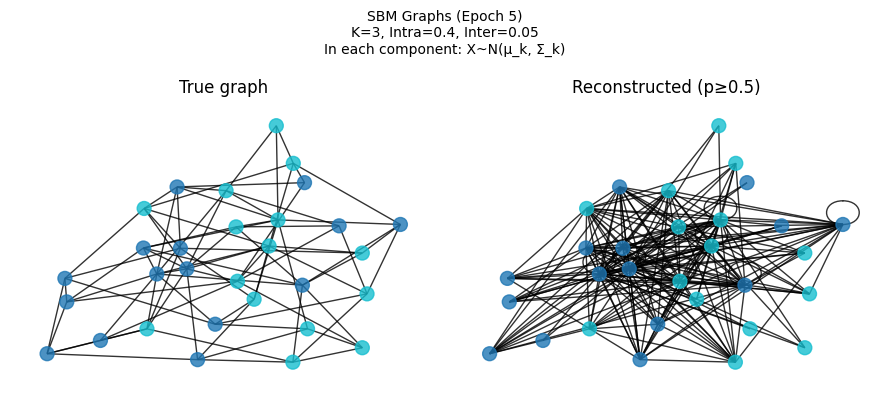

Epoch 006, Total Loss: 42845.35, NLL Loss: 1055.90, KLD Loss: 15.23
Epoch 007, Total Loss: 42721.45, NLL Loss: 1053.44, KLD Loss: 14.60
Epoch 008, Total Loss: 42670.65, NLL Loss: 1052.39, KLD Loss: 14.38
Epoch 009, Total Loss: 42659.17, NLL Loss: 1052.31, KLD Loss: 14.17
Epoch 010, Total Loss: 42619.68, NLL Loss: 1051.51, KLD Loss: 13.99


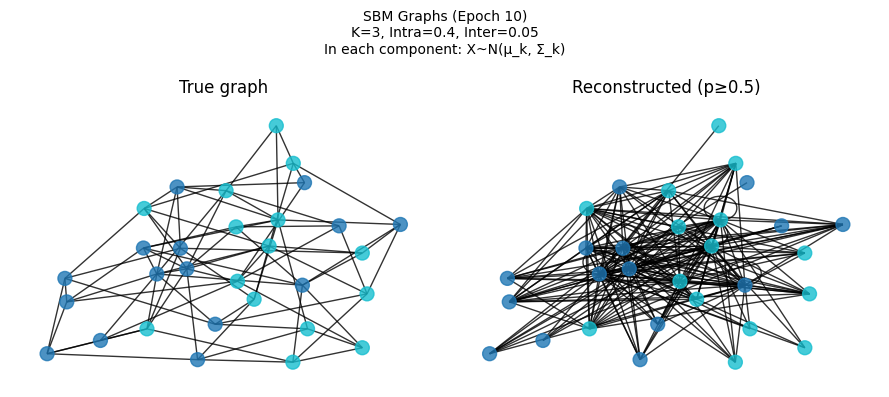

Epoch 011, Total Loss: 42608.28, NLL Loss: 1051.45, KLD Loss: 13.75
Epoch 012, Total Loss: 42579.43, NLL Loss: 1050.71, KLD Loss: 13.78
Epoch 013, Total Loss: 42511.08, NLL Loss: 1049.12, KLD Loss: 13.66
Epoch 014, Total Loss: 42504.76, NLL Loss: 1049.05, KLD Loss: 13.57
Epoch 015, Total Loss: 42448.24, NLL Loss: 1047.68, KLD Loss: 13.53


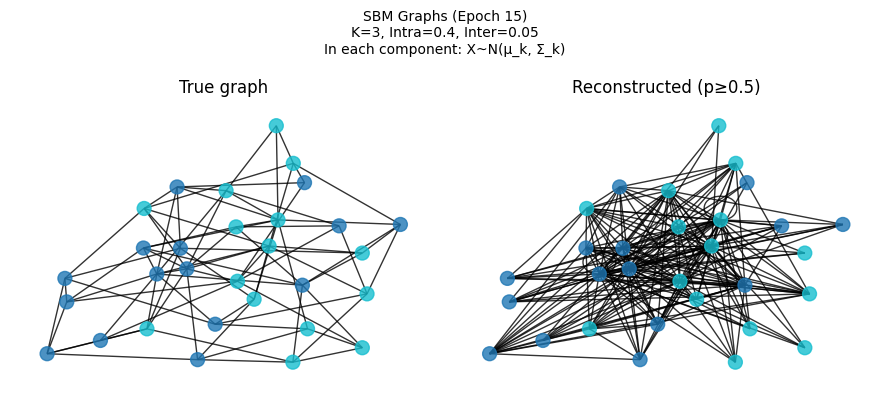

Epoch 016, Total Loss: 42479.68, NLL Loss: 1048.45, KLD Loss: 13.54
Epoch 017, Total Loss: 42540.66, NLL Loss: 1049.16, KLD Loss: 14.36
Epoch 018, Total Loss: 42451.13, NLL Loss: 1047.84, KLD Loss: 13.44
Epoch 019, Total Loss: 42461.17, NLL Loss: 1047.89, KLD Loss: 13.64
Epoch 020, Total Loss: 42399.35, NLL Loss: 1046.69, KLD Loss: 13.29


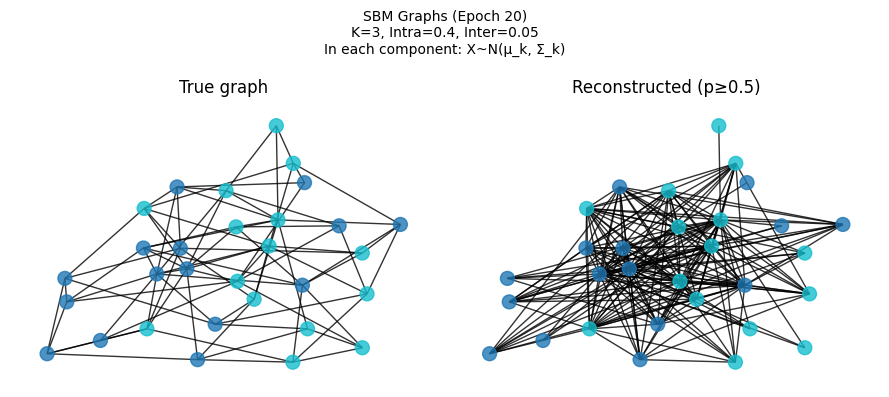

Epoch 021, Total Loss: 42377.08, NLL Loss: 1046.02, KLD Loss: 13.41
Epoch 023, Total Loss: 42352.85, NLL Loss: 1045.49, KLD Loss: 13.33
Epoch 024, Total Loss: 42353.83, NLL Loss: 1045.55, KLD Loss: 13.29
Epoch 025, Total Loss: 42368.97, NLL Loss: 1045.90, KLD Loss: 13.32


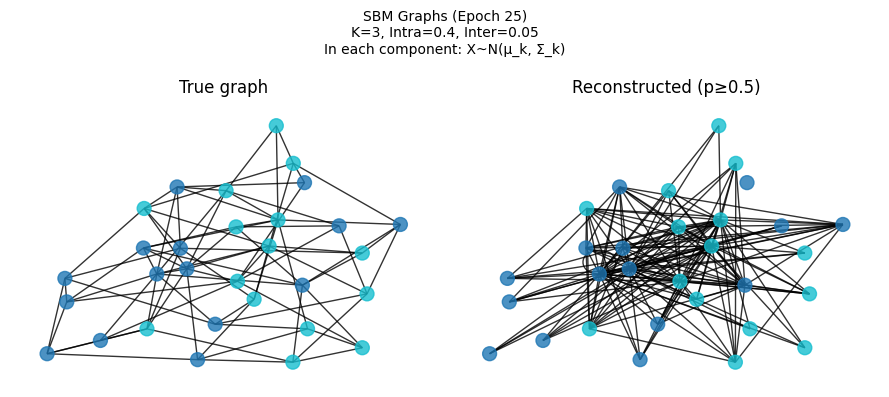

Epoch 026, Total Loss: 42298.95, NLL Loss: 1044.21, KLD Loss: 13.26
Epoch 027, Total Loss: 42375.11, NLL Loss: 1046.10, KLD Loss: 13.28
Epoch 028, Total Loss: 42290.73, NLL Loss: 1044.00, KLD Loss: 13.27
Epoch 029, Total Loss: 42286.42, NLL Loss: 1043.86, KLD Loss: 13.30
Epoch 030, Total Loss: 42304.26, NLL Loss: 1044.27, KLD Loss: 13.34


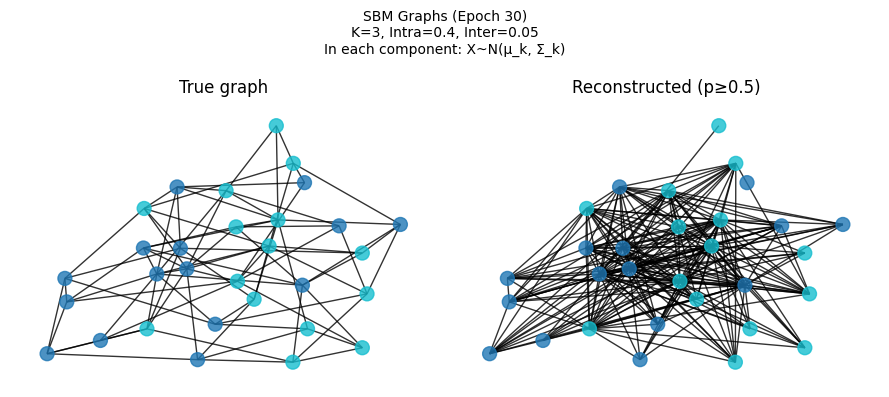

Epoch 031, Total Loss: 42290.41, NLL Loss: 1044.06, KLD Loss: 13.20
Epoch 032, Total Loss: 42318.58, NLL Loss: 1044.70, KLD Loss: 13.26
Epoch 033, Total Loss: 42338.00, NLL Loss: 1045.12, KLD Loss: 13.33
Epoch 034, Total Loss: 42247.21, NLL Loss: 1042.91, KLD Loss: 13.27
Epoch 035, Total Loss: 42310.52, NLL Loss: 1044.52, KLD Loss: 13.24


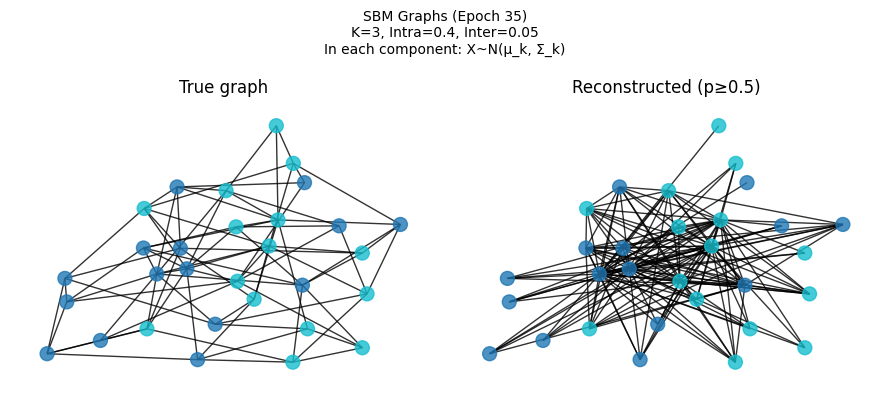

Epoch 036, Total Loss: 42267.24, NLL Loss: 1043.55, KLD Loss: 13.13
Epoch 037, Total Loss: 42264.72, NLL Loss: 1043.35, KLD Loss: 13.27
Epoch 038, Total Loss: 42255.86, NLL Loss: 1043.28, KLD Loss: 13.12
Epoch 039, Total Loss: 42265.98, NLL Loss: 1043.43, KLD Loss: 13.22
Epoch 040, Total Loss: 42273.23, NLL Loss: 1043.68, KLD Loss: 13.15


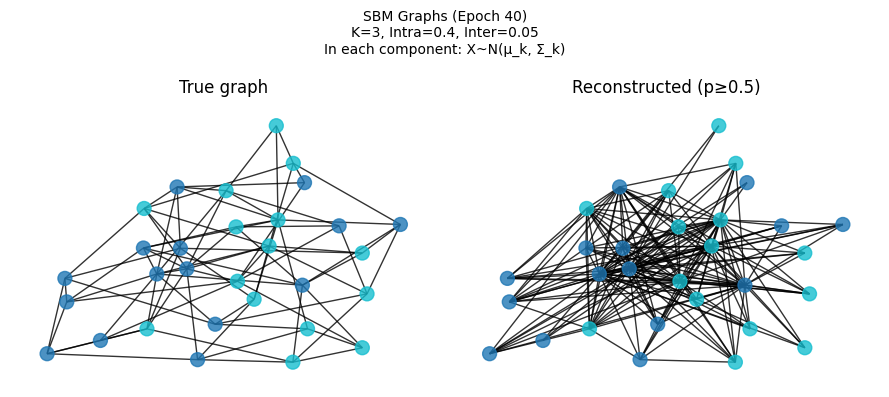

Epoch 041, Total Loss: 42248.34, NLL Loss: 1043.08, KLD Loss: 13.12
Epoch 042, Total Loss: 42208.87, NLL Loss: 1042.07, KLD Loss: 13.15
Epoch 043, Total Loss: 42201.61, NLL Loss: 1041.91, KLD Loss: 13.13
Epoch 044, Total Loss: 42221.06, NLL Loss: 1042.47, KLD Loss: 13.06
Epoch 045, Total Loss: 42241.96, NLL Loss: 1042.88, KLD Loss: 13.17


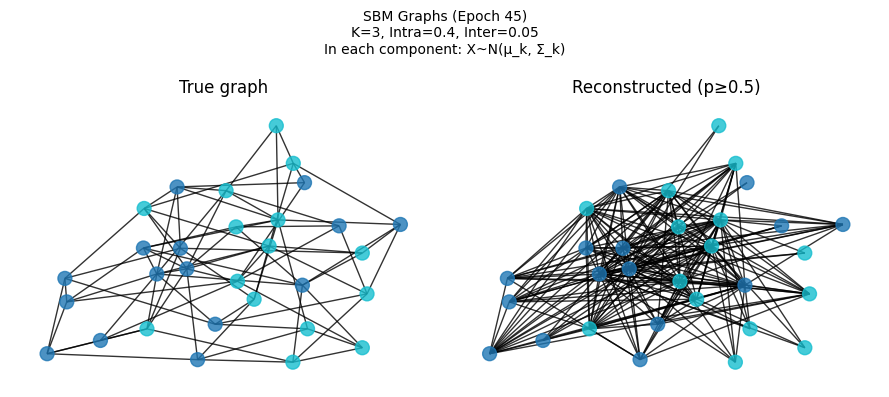

Epoch 046, Total Loss: 42221.49, NLL Loss: 1042.61, KLD Loss: 12.93
Epoch 047, Total Loss: 42185.35, NLL Loss: 1041.72, KLD Loss: 12.92
Epoch 048, Total Loss: 42272.75, NLL Loss: 1043.85, KLD Loss: 12.97
Epoch 049, Total Loss: 42188.34, NLL Loss: 1041.69, KLD Loss: 13.02
Epoch 050, Total Loss: 42191.81, NLL Loss: 1041.78, KLD Loss: 13.01


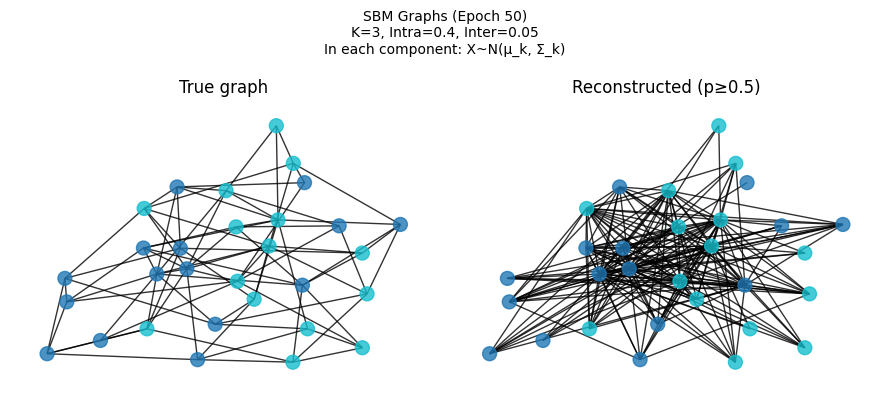

Epoch 051, Total Loss: 42210.24, NLL Loss: 1042.24, KLD Loss: 13.02
Epoch 052, Total Loss: 42151.84, NLL Loss: 1040.74, KLD Loss: 13.06
Epoch 053, Total Loss: 42173.89, NLL Loss: 1041.36, KLD Loss: 12.99
Epoch 054, Total Loss: 42179.59, NLL Loss: 1041.52, KLD Loss: 12.97
Epoch 055, Total Loss: 42189.79, NLL Loss: 1041.87, KLD Loss: 12.88


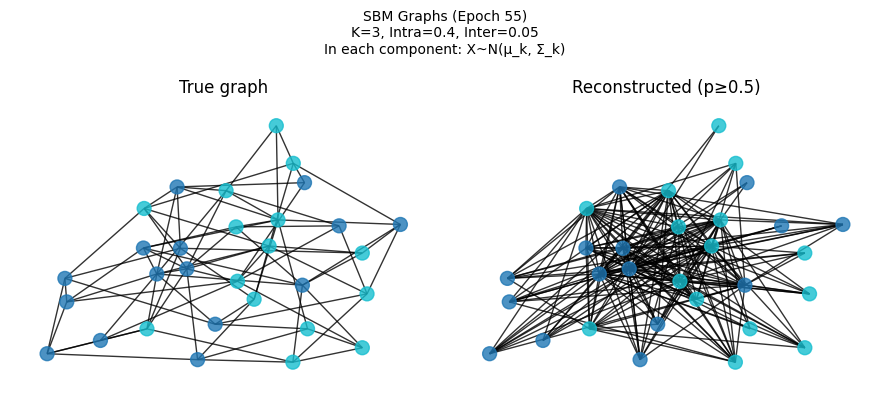

Epoch 056, Total Loss: 42133.09, NLL Loss: 1040.55, KLD Loss: 12.77
Epoch 057, Total Loss: 42158.43, NLL Loss: 1041.10, KLD Loss: 12.86
Epoch 058, Total Loss: 42131.40, NLL Loss: 1040.33, KLD Loss: 12.95
Epoch 059, Total Loss: 42199.43, NLL Loss: 1041.90, KLD Loss: 13.09
Epoch 060, Total Loss: 42193.12, NLL Loss: 1041.68, KLD Loss: 13.15


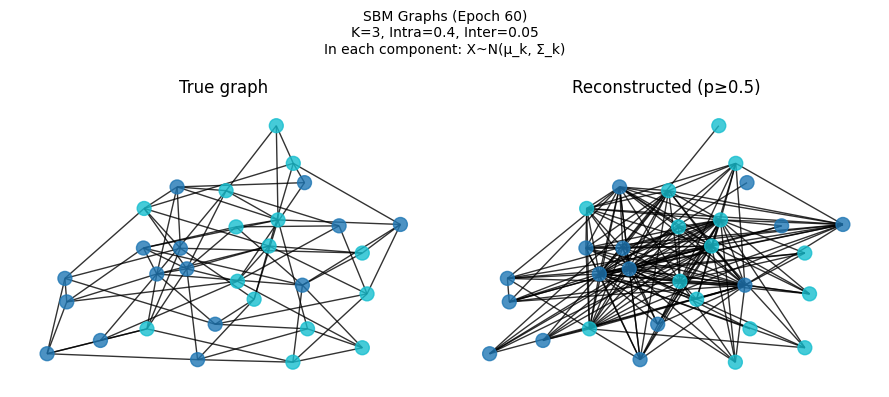

Epoch 061, Total Loss: 42147.52, NLL Loss: 1040.82, KLD Loss: 12.87
Epoch 062, Total Loss: 42168.97, NLL Loss: 1041.29, KLD Loss: 12.93
Epoch 063, Total Loss: 42195.39, NLL Loss: 1042.05, KLD Loss: 12.84
Epoch 064, Total Loss: 42138.78, NLL Loss: 1040.71, KLD Loss: 12.76
Epoch 065, Total Loss: 42206.45, NLL Loss: 1042.39, KLD Loss: 12.77


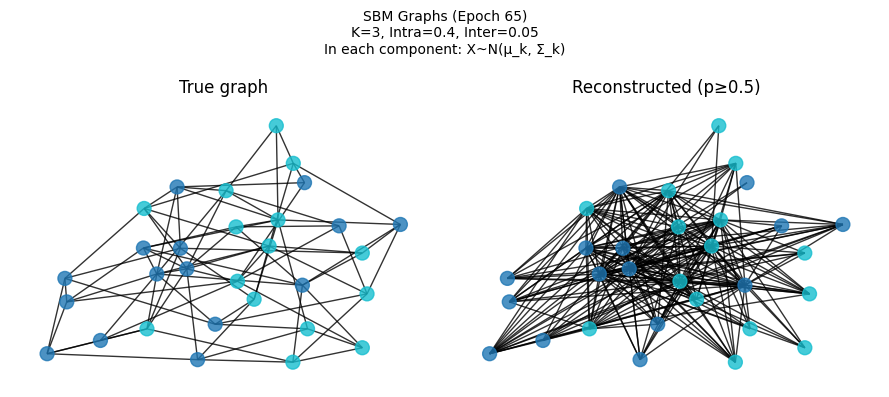

Epoch 066, Total Loss: 42156.67, NLL Loss: 1041.12, KLD Loss: 12.80
Epoch 067, Total Loss: 42182.72, NLL Loss: 1041.79, KLD Loss: 12.78
Epoch 068, Total Loss: 42136.14, NLL Loss: 1040.67, KLD Loss: 12.73
Epoch 069, Total Loss: 42183.83, NLL Loss: 1041.76, KLD Loss: 12.83
Epoch 070, Total Loss: 42093.90, NLL Loss: 1039.54, KLD Loss: 12.80


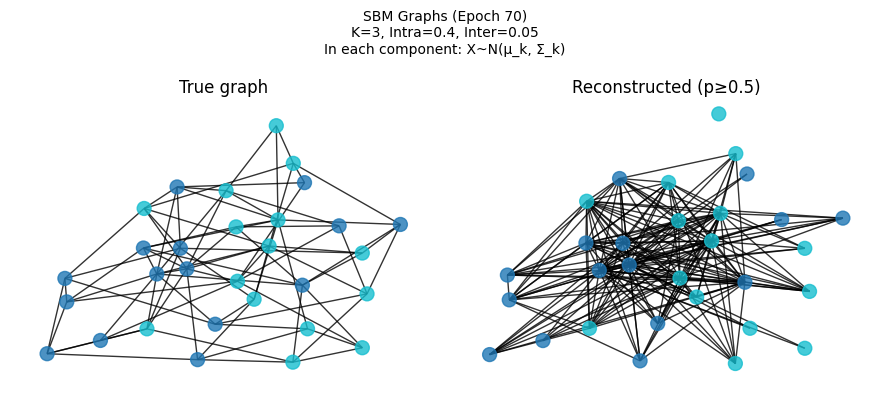

Epoch 071, Total Loss: 42167.91, NLL Loss: 1041.34, KLD Loss: 12.86
Epoch 072, Total Loss: 42094.84, NLL Loss: 1039.44, KLD Loss: 12.93
Epoch 073, Total Loss: 42117.92, NLL Loss: 1040.10, KLD Loss: 12.85
Epoch 074, Total Loss: 42136.63, NLL Loss: 1040.58, KLD Loss: 12.84
Epoch 075, Total Loss: 42181.38, NLL Loss: 1041.68, KLD Loss: 12.86


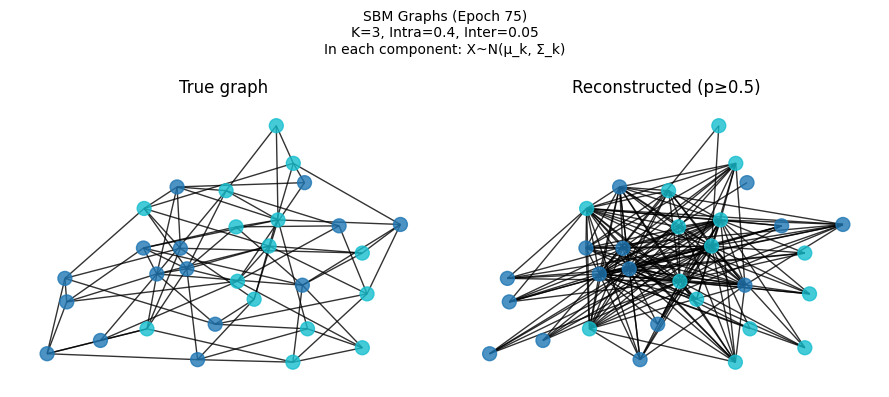

Epoch 076, Total Loss: 42218.52, NLL Loss: 1042.57, KLD Loss: 12.90
Epoch 077, Total Loss: 42077.05, NLL Loss: 1039.20, KLD Loss: 12.73
Epoch 078, Total Loss: 42119.85, NLL Loss: 1040.32, KLD Loss: 12.68
Epoch 079, Total Loss: 42084.02, NLL Loss: 1039.31, KLD Loss: 12.79
Epoch 080, Total Loss: 42115.61, NLL Loss: 1040.09, KLD Loss: 12.80


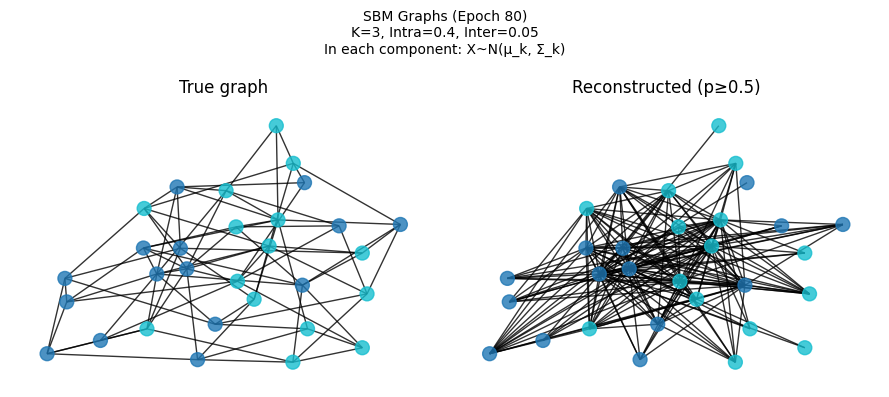

Epoch 081, Total Loss: 42138.60, NLL Loss: 1040.65, KLD Loss: 12.81
Epoch 082, Total Loss: 42150.33, NLL Loss: 1041.02, KLD Loss: 12.73
Epoch 083, Total Loss: 42116.25, NLL Loss: 1040.15, KLD Loss: 12.76
Epoch 084, Total Loss: 42095.43, NLL Loss: 1039.57, KLD Loss: 12.81
Epoch 085, Total Loss: 42134.81, NLL Loss: 1040.46, KLD Loss: 12.91


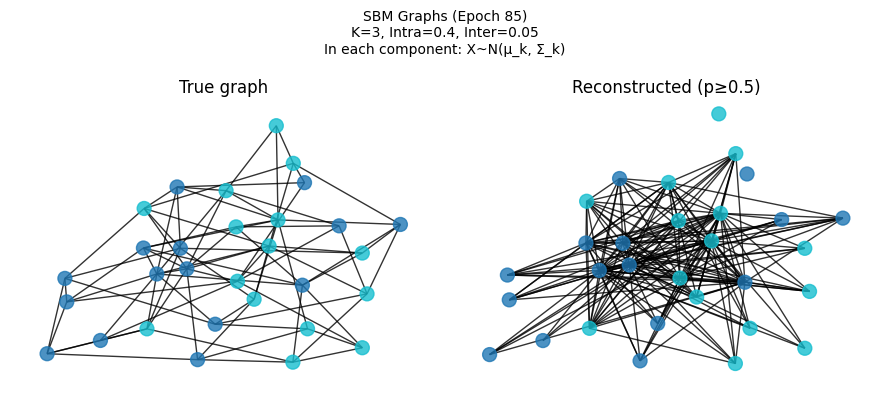

Epoch 086, Total Loss: 42062.28, NLL Loss: 1038.63, KLD Loss: 12.93
Epoch 087, Total Loss: 42224.47, NLL Loss: 1042.54, KLD Loss: 13.07
Epoch 088, Total Loss: 42117.32, NLL Loss: 1040.12, KLD Loss: 12.81
Epoch 089, Total Loss: 42094.31, NLL Loss: 1039.66, KLD Loss: 12.69
Epoch 090, Total Loss: 42096.76, NLL Loss: 1039.34, KLD Loss: 13.08


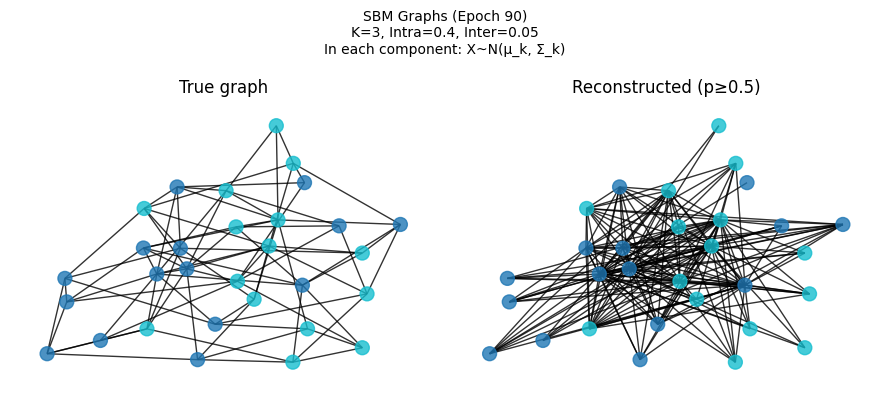

Epoch 091, Total Loss: 42064.75, NLL Loss: 1038.55, KLD Loss: 13.07
Epoch 092, Total Loss: 42102.70, NLL Loss: 1039.72, KLD Loss: 12.85
Epoch 093, Total Loss: 42092.76, NLL Loss: 1039.56, KLD Loss: 12.76
Epoch 094, Total Loss: 42118.92, NLL Loss: 1040.08, KLD Loss: 12.89
Epoch 095, Total Loss: 42176.31, NLL Loss: 1041.32, KLD Loss: 13.09


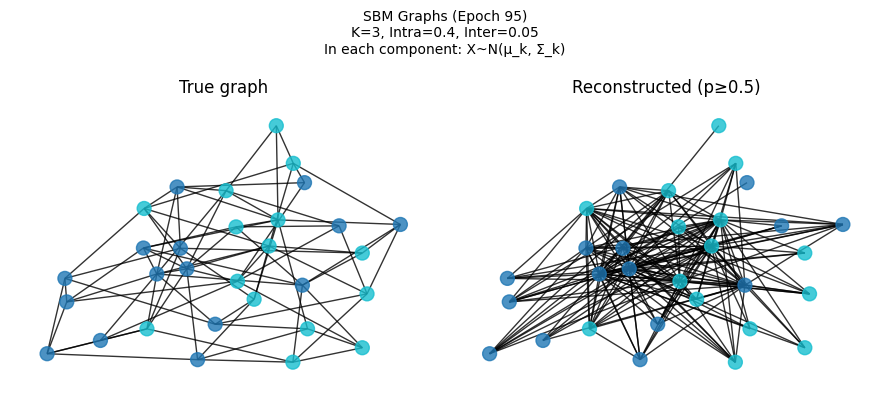

Epoch 096, Total Loss: 42040.86, NLL Loss: 1038.22, KLD Loss: 12.80
Epoch 097, Total Loss: 42083.43, NLL Loss: 1039.28, KLD Loss: 12.81
Epoch 098, Total Loss: 42114.77, NLL Loss: 1040.03, KLD Loss: 12.84
Epoch 099, Total Loss: 42128.79, NLL Loss: 1040.52, KLD Loss: 12.69
Epoch 100, Total Loss: 42053.98, NLL Loss: 1038.66, KLD Loss: 12.69


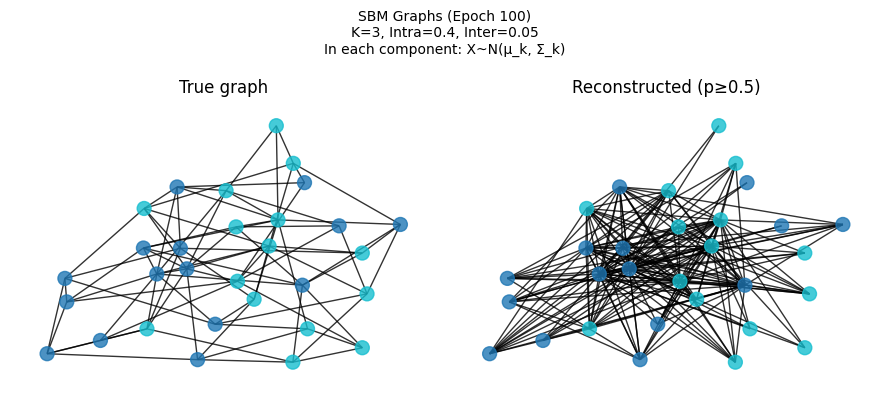

Test Set - Total Loss: 42001.78, NLL Loss: 1037.38, KLD Loss: 12.66
Edge accuracy (last snapshot): 61.39%


In [35]:
if __name__ == "__main__":
    model, dataset = train_model(vis_interval=5, epochs=100)
    test_model(model, dataset)

# Question 2: Conditional Variational Autoencoder (CVAE) for Digit Generation

This note introduces a **Conditional Variational Autoencoder (CVAE)** for image generation on the **MNIST** dataset. The goal is to learn a deep latent-variable model that can synthesize digits conditioned on a desired label—e.g., generate a “2” on demand—and optionally modulate the writing style.


## **Problem setup**

We observe training pairs of handwritten digits and their class labels
$$
\mathcal{D} = {(x^{(i)}, y^{(i)})}_{i=1}^N,
$$
where $x^{(i)} \in \mathbb{R}^{28\times28}$ is an image and $y^{(i)} \in {0,\dots,9}$ is the corresponding digit label.
Our goal is to model the conditional data distribution
$$
p_\theta(x \mid y),
$$
so that, given any label $y$, the model can generate realistic samples $x$ of that digit.



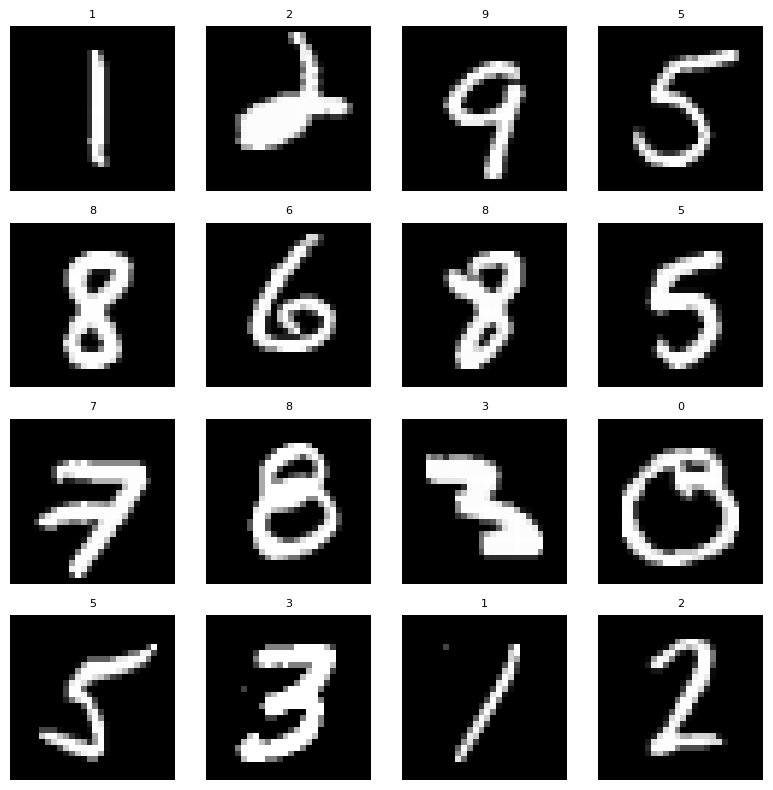

In [17]:
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
import random
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader

# data visualization
def show_grid(images, titles=None, nrows=4, ncols=4, figsize=(8,8)):
    plt.figure(figsize=figsize)
    for i in range(nrows * ncols):
        plt.subplot(nrows, ncols, i + 1)
        img = images[i]
        if isinstance(img, torch.Tensor):
            img = img.squeeze().cpu().numpy()
        plt.imshow(img, cmap='gray')
        plt.axis('off')
        if titles is not None:
            plt.title(titles[i], fontsize=8)
    plt.tight_layout()
    plt.show()

dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transforms.ToTensor())
dataloader = DataLoader(dataset, batch_size=16, shuffle=True)
data_iter = iter(dataloader)
images_batch, labels_batch = next(data_iter)
imgs = images_batch[:16]
labs = labels_batch[:16]
show_grid([img for img in imgs], titles=[str(int(l)) for l in labs], nrows=4, ncols=4)

### **Model setup**

We introduce a latent variable $ z \in \mathbb{R}^m $ that captures continuous variations in handwriting style.
The joint distribution is defined as

$$
p_\theta(x, z \mid y) = p_\theta(x \mid z, y) p(z),
$$

where $ p(z) = \mathcal{N}(0, I) $ is a fixed Gaussian prior.

* **Decoder (generative model):** $ p_\theta(x \mid z, y) $ reconstructs the image given latent code $z$ and label $y$.
* **Encoder (inference model):** we approximate the true posterior $ p_\theta(z \mid x, y) $ with

$$
q_\phi(z \mid x, y) = \mathcal{N}\big(\mu_\phi(x, y), \mathrm{diag}(\sigma_\phi^2(x, y))\big).
$$



### **Derivation of the Conditional ELBO**

Our goal is to maximize the conditional log-likelihood of the data:

$$
\log p_\theta(x \mid y).
$$

Since this is intractable, we derive a lower bound (the **conditional ELBO**):

$$
\log p_\theta(x \mid y)
\ge
\mathbb{E}_{q_\phi(z \mid x, y)}[\log p_\theta(x \mid z, y)]
-
D_{\mathrm{KL}}\big(q_\phi(z \mid x, y) | p(z)\big).
$$

### **Training objective**

The right-hand side is the objective we actually optimize.
We **maximize** the ELBO with respect to parameters $\theta$ and $\phi$, or equivalently, **minimize** the negative ELBO (which is used as the loss in code):

$$
\mathcal{L}_{\text{CVAE}}(x, y)
= -\mathbb{E}_{q_\phi(z \mid x, y)}[\log p_\theta(x \mid z, y)]
+ D_{\mathrm{KL}}\big(q_\phi(z \mid x, y) | p(z)\big).
$$

- The first term (reconstruction loss) ensures that decoded samples resemble the input image.
- The second term (KL divergence) regularizes the latent distribution so that it stays close to the Gaussian prior, which keeps sampling stable during generation.




In [2]:
# models
class Encoder(nn.Module):
    def __init__(self, y_dim, z_dim):
        super().__init__()
        self.y_dim = y_dim
        self.z_dim = z_dim
        self.fc1 = nn.Linear(28 * 28 + y_dim, 400)
        self.fc_mu = nn.Linear(400, z_dim)
        self.fc_logvar = nn.Linear(400, z_dim)

    def forward(self, x, y):
        x = x.view(x.size(0), -1)
        x = torch.cat([x, y], dim=1)
        h = F.relu(self.fc1(x))
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

class Decoder(nn.Module):
    def __init__(self, y_dim, z_dim):
        super().__init__()
        self.y_dim = y_dim
        self.z_dim = z_dim
        self.fc1 = nn.Linear(z_dim + y_dim, 400)
        self.fc2 = nn.Linear(400, 28 * 28)

    def forward(self, z, y):
        z = torch.cat([z, y], dim=1)
        h = F.relu(self.fc1(z))
        x_recon = torch.sigmoid(self.fc2(h))
        x_recon = x_recon.view(-1, 1, 28, 28)
        return x_recon

class CVAE(nn.Module):
    def __init__(self, y_dim=10, z_dim=20):
        super().__init__()
        self.encoder = Encoder(y_dim, z_dim)
        self.decoder = Decoder(y_dim, z_dim)

    def reparameterize(self, mu, logvar):
        eps = torch.randn_like(mu)
        std = torch.exp(0.5 * logvar)
        return mu + eps * std

    def forward(self, x, y):
        if y.shape[-1] != 10:
            y = F.one_hot(y, num_classes=10).float().to(y.device)
        mu, logvar = self.encoder(x, y)
        z = self.reparameterize(mu, logvar)
        x_recon = self.decoder(z, y)
        return x_recon, mu, logvar

In [3]:
# loss
def loss_function(x_recon, x, mu, logvar):
    # reconstruction loss (binary cross-entropy)
    recon_loss = F.binary_cross_entropy(x_recon, x, reduction='sum')

    # KL divergence between q(z|x,y) and N(0,I)
    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())

    return recon_loss + kl_loss, recon_loss, kl_loss

In [8]:
# training
# dataloader
batch_size = 128
train_loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CVAE(y_dim=10, z_dim=20).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=3e-3)

epochs = 10
### don't edit this !!!
for epoch in range(1, epochs+1):
    model.train()
    total_loss = 0.0
    total_recon = 0.0
    total_kl = 0.0
    for x, y in train_loader:
        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad()
        x_recon, mu, logvar = model(x, y)

        loss, recon_loss, kl_loss = loss_function(x_recon, x, mu, logvar)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_recon += recon_loss.item()
        total_kl += kl_loss.item()

    n = len(train_loader.dataset)
    print(f"Epoch {epoch:02d}  Loss per example: {total_loss / n:.4f}  Recon: {total_recon / n:.4f}  KL: {total_kl / n:.4f}")


Epoch 01  Loss per example: 143.6254  Recon: 129.9230  KL: 13.7024
Epoch 02  Loss per example: 112.0983  Recon: 92.7138  KL: 19.3845
Epoch 03  Loss per example: 107.5859  Recon: 87.4338  KL: 20.1521
Epoch 04  Loss per example: 105.5142  Recon: 85.0568  KL: 20.4574
Epoch 05  Loss per example: 104.2668  Recon: 83.6514  KL: 20.6154
Epoch 06  Loss per example: 103.3231  Recon: 82.6785  KL: 20.6445
Epoch 07  Loss per example: 102.7510  Recon: 82.0468  KL: 20.7042
Epoch 08  Loss per example: 102.2561  Recon: 81.4908  KL: 20.7653
Epoch 09  Loss per example: 101.7035  Recon: 80.9405  KL: 20.7630
Epoch 10  Loss per example: 101.3396  Recon: 80.6020  KL: 20.7376


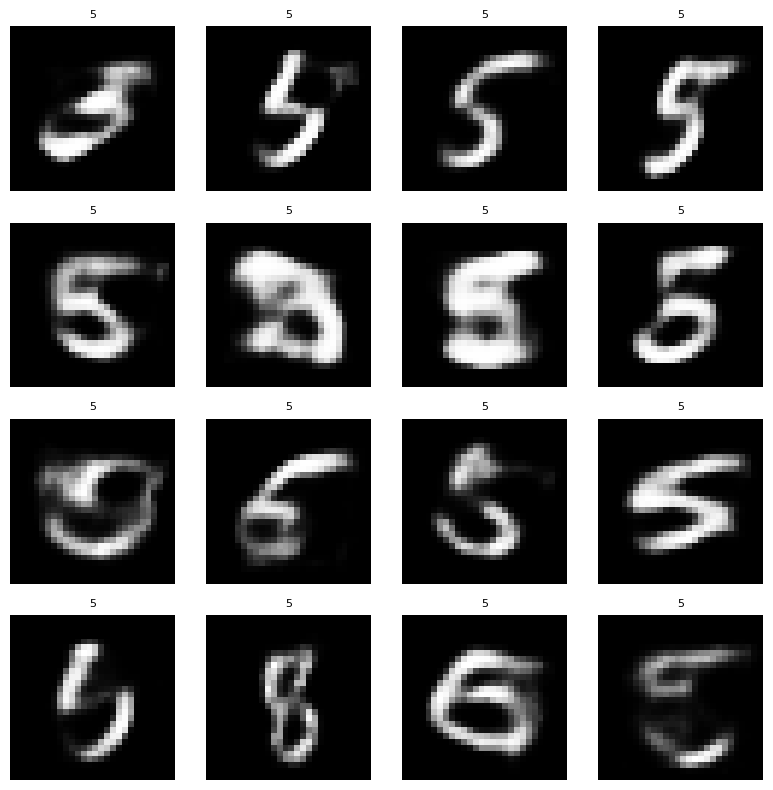

In [9]:
# model inferencing
model.eval()
with torch.no_grad():
    # choose the digit you want to generate
    digit = 5   # for example, "2"
    n = 16
    y = torch.zeros(n, 10).to(device)
    y[:, digit] = 1

    # match the latent size to your model (z_dim=32)
    z = torch.randn(n, 20).to(device)

    # decode to images
    x_gen = model.decoder(z, y).cpu()

# visualize
show_grid([img for img in x_gen], titles=[str(digit)]*16, nrows=4, ncols=4)

### Student ID Generation
After training your CVAE model, define a function that takes your 9-digit student ID as input and generates one digit per number in your ID. Each digit must be conditioned on its corresponding label (0–9). Arrange the generated digits horizontally in a 1×9 grid to visually display your complete student ID as a sequence of generated MNIST-style digits. Include this final generated image in your report.

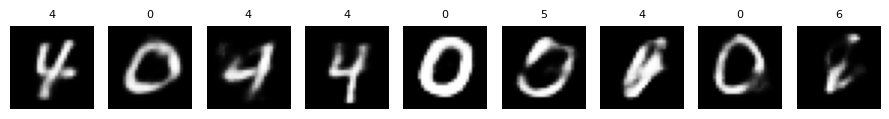

In [10]:
def generate_student_id(model, student_id, device='cpu', z_dim=20):
    s = str(student_id)

    model.eval()
    imgs = []
    titles = []
    with torch.no_grad():
        for ch in s:
            digit = int(ch)
            y = F.one_hot(torch.tensor([digit]), num_classes=10).float().to(device)
            z = torch.randn(1, z_dim).to(device)
            x_gen = model.decoder(z, y)
            imgs.append(x_gen.squeeze(0).cpu())
            titles.append(str(digit))

    show_grid(imgs, titles=titles, nrows=1, ncols=9, figsize=(9, 2))

    return torch.stack(imgs, dim=0)

generated_images = generate_student_id(model, "404405406", device=device, z_dim=20)

### **Latent Space Exploration**
To demonstrate that your CVAE has learned a meaningful latent representation, write a function that visualizes the latent space of the model.
Select **two random latent directions** in $z$-space, fix a target digit label $y$, and generate a **9×9 grid** of samples by varying these two directions from negative to positive values.
The center of the grid should correspond to $z = 0$ (the mean latent vector), while moving along the axes explores different variations of handwriting style.
After visualizing, **describe what each direction appears to represent**—for example, changes in stroke thickness, slant, or digit shape—and discuss whether the transformations look smooth and interpretable.


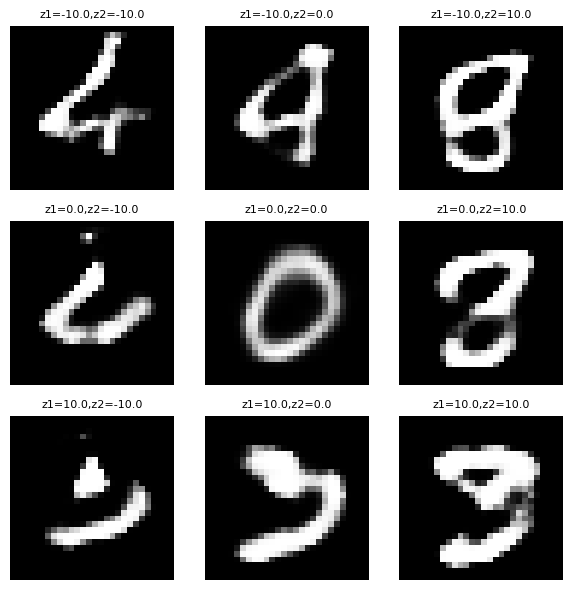

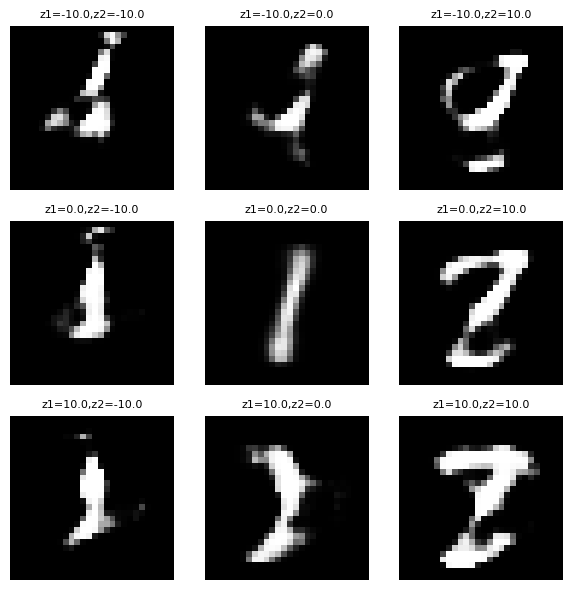

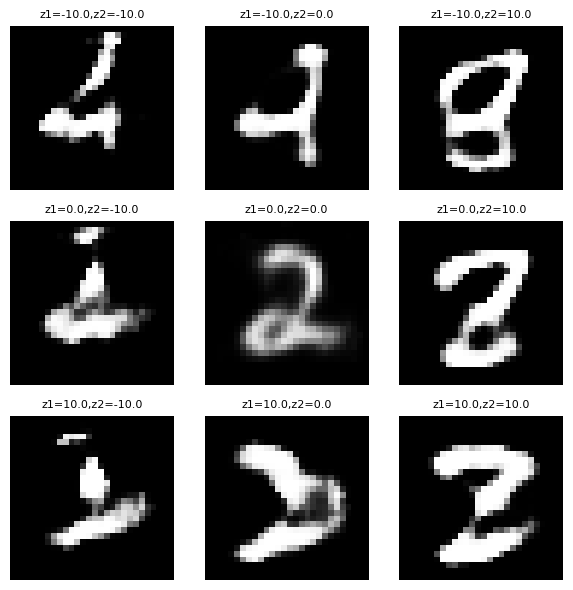

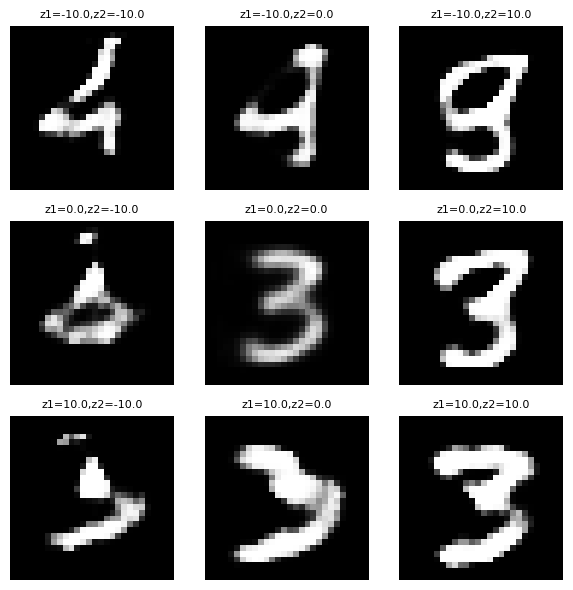

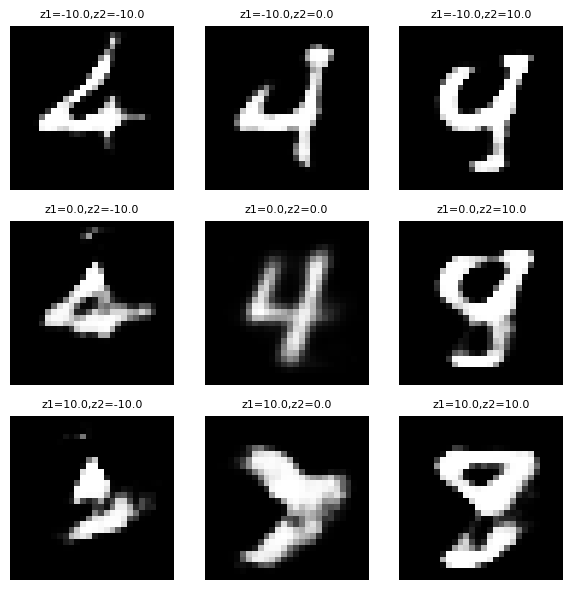

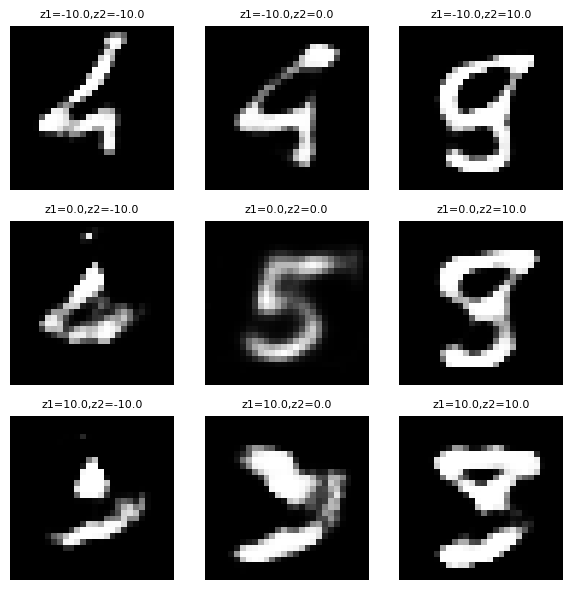

In [15]:
def visualize_latent_space(model, y_label, z_dim=20, grid_size=10, scale=3, device='cpu'):
    model.eval()
    digit = y_label
    imgs = []
    titles = []
    with torch.no_grad():
        y = F.one_hot(torch.tensor([digit]), num_classes=10).float().to(device)

        for i in range(grid_size):
            for j in range(grid_size):
                z1 = scale * (i / (grid_size - 1) - 0.5) * 2
                z2 = scale * (j / (grid_size - 1) - 0.5) * 2
                z = torch.zeros(1, z_dim).to(device)
                if z_dim >= 2:
                    z[0, 0] = z1
                    z[0, 1] = z2
                else:
                    z[0, 0] = z1

                x_gen = model.decoder(z, y)
                imgs.append(x_gen.squeeze(0).cpu())
                titles.append(f"z1={z1:.1f},z2={z2:.1f}")
    show_grid(imgs, titles=titles, nrows=grid_size, ncols=grid_size, figsize=(grid_size*2, grid_size*2))

visualize_latent_space(model, y_label=0, z_dim=20, grid_size=3, scale=10, device=device)
visualize_latent_space(model, y_label=1, z_dim=20, grid_size=3, scale=10, device=device)
visualize_latent_space(model, y_label=2, z_dim=20, grid_size=3, scale=10, device=device)
visualize_latent_space(model, y_label=3, z_dim=20, grid_size=3, scale=10, device=device)
visualize_latent_space(model, y_label=4, z_dim=20, grid_size=3, scale=10, device=device)
visualize_latent_space(model, y_label=5, z_dim=20, grid_size=3, scale=10, device=device)



### **Bonus – Style-Controlled Student ID Generation**
Extend your CVAE to allow **style control** along a latent dimension.
Write a function that takes your **9-digit student ID** as input and generates one digit per number, arranged in a single row.
Additionally, for each digit, gradually vary the “style” dimension from thin to thick (or light to bold) as you move across the row, so that the same digit shows different styles.
Include the resulting image in your report and briefly describe how the style changes are reflected in the generated digits.


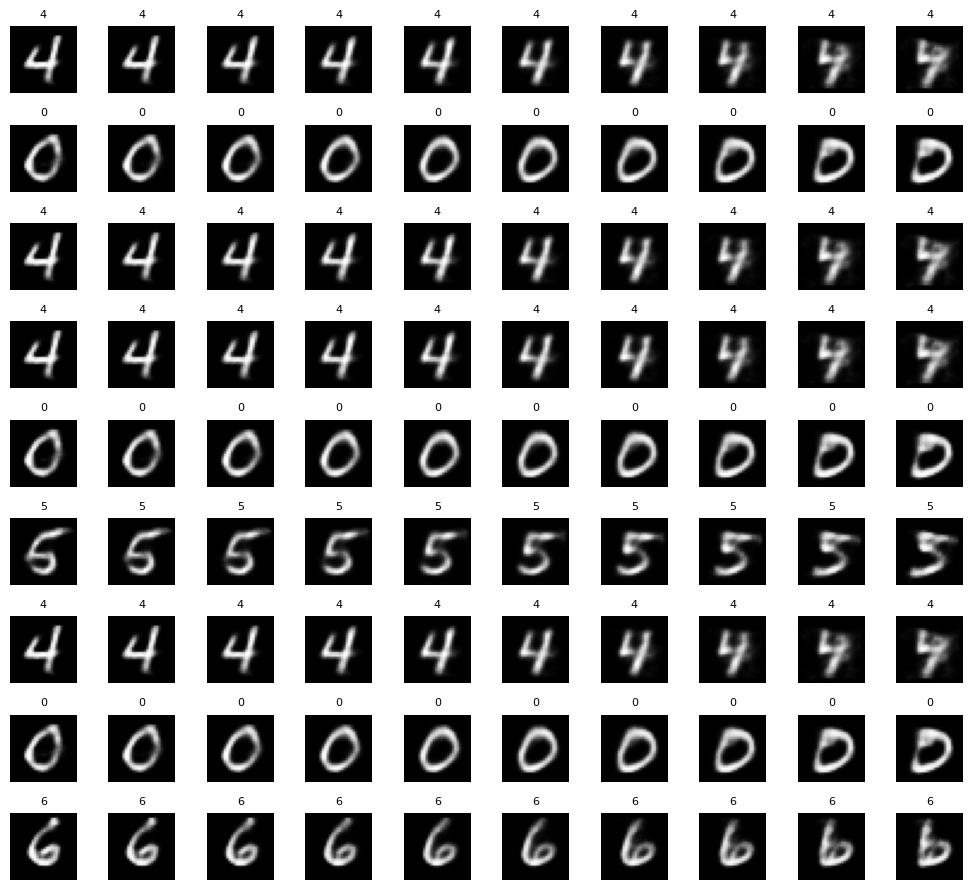

Description: each group of images corresponds to one digit of the student ID.
Within each group (left->right) the chosen latent dimension is swept from negative to positive,
so visual changes (e.g., stroke thickness, slant, or digit width) indicate how that latent controls style.


In [23]:
def generate_style_controlled_student_id(model, student_id, device='cpu', z_dim=20, style_dim=0, steps=9, scale=3.0):
    s = str(student_id)
    assert len(s) == 9, "student_id must be 9 digits"
    assert 0 <= style_dim < z_dim, "style_dim must be a valid latent index"

    model.eval()
    imgs = []
    titles = []
    device = torch.device(device)
    with torch.no_grad():
        for ch in s:
            digit = int(ch)
            y = F.one_hot(torch.tensor([digit]), num_classes=10).float().to(device)
            for v in np.linspace(-scale, scale, steps):
                z = torch.zeros(1, z_dim).to(device)
                z[0, style_dim] = float(v)
                x_gen = model.decoder(z, y)
                imgs.append(x_gen.squeeze(0).cpu())
                titles.append(str(digit))

    show_grid(imgs, titles=titles, nrows=9, ncols=steps, figsize=(steps, 9))

    return torch.stack(imgs, dim=0)

imgs = generate_style_controlled_student_id(model, "404405406", device=device, z_dim=20, style_dim=0, steps=10, scale=3.0)